In [2]:
RANDOM_STATE = 42
N_TRIALS = 400
N_JOBS = -1

In [3]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['target'] = df['target']

df.columns = df.columns.str.replace('/', '_')

print(df.info())
print(df['target'].value_counts())
#print(wine.DESCR)

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280_od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

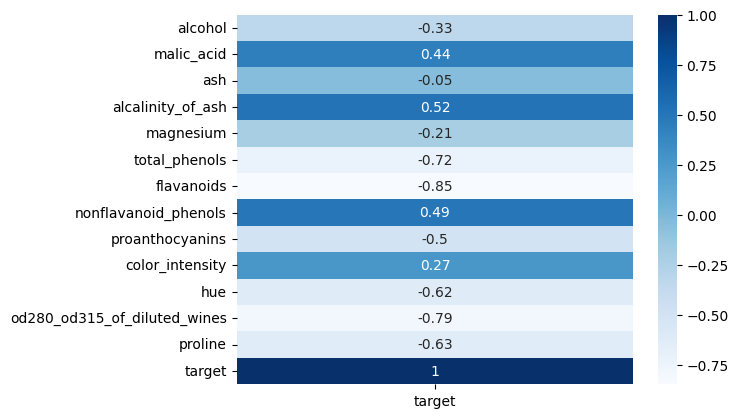

<Figure size 640x480 with 0 Axes>

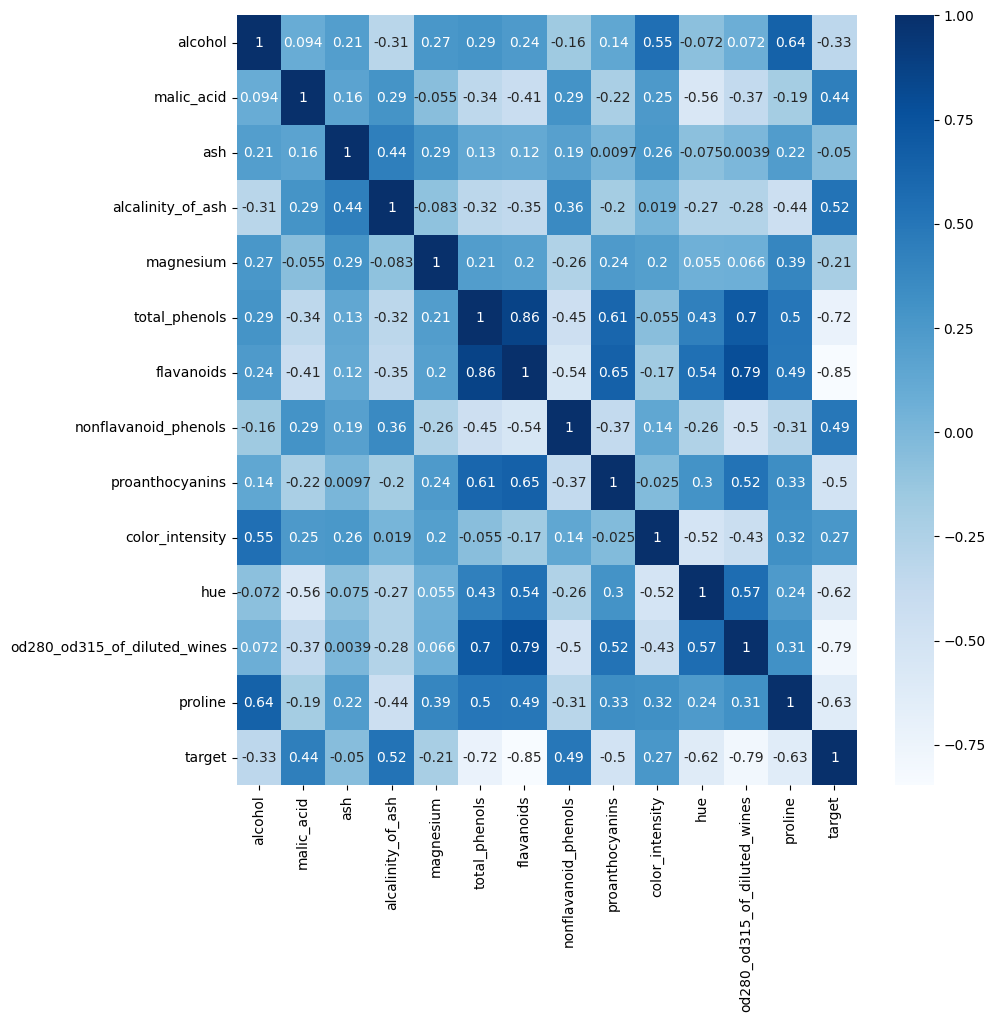

<Figure size 640x480 with 0 Axes>

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr()['target'].to_frame(), annot=True, cmap='Blues')
plt.show()
plt.clf()

plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.show()
plt.clf()

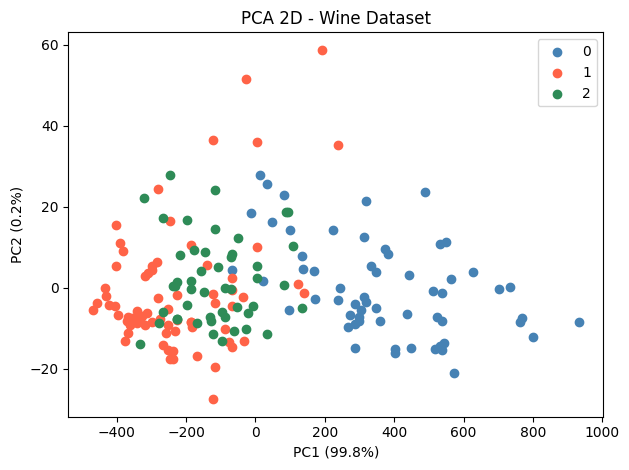

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(df.drop(columns=['target']))
y_axis = df['target']

colors = ['steelblue', 'tomato', 'seagreen']

added = set()
for i, y in zip(components, y_axis):
    plt.scatter(i[0], i[1],c=colors[y], label=y if y not in added else None)
    added.add(y)

plt.legend()
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA 2D - Wine Dataset')
plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=RANDOM_STATE)

In [7]:
from xgboost import XGBClassifier
import optuna 
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True), 
        'max_depth': trial.suggest_int('max_depth', 3, 10), 
        'n_estimators': trial.suggest_int('n_estimators', 100, 500), 
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),    
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0), 
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 20), 
        'gamma': trial.suggest_float('gamma', 0.0, 5.0), 
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        #'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0), #Usare solo sulle due categorie
        'n_jobs': N_JOBS,
        'random_state': RANDOM_STATE
    }

    model = XGBClassifier(**params)
    return cross_val_score(model, x_train, y_train, cv=5, scoring='f1_weighted').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(study.best_params)

/home/dave/git/CodeAcademy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 281. Best value: 0.992308: 100%|██████████| 400/400 [06:36<00:00,  1.01it/s]

{'learning_rate': 0.005936302995364575, 'max_depth': 6, 'n_estimators': 298, 'subsample': 0.8038749906817372, 'colsample_bytree': 0.5516833098495556, 'colsample_bylevel': 0.5587116618875284, 'colsample_bynode': 0.6567343542727014, 'min_child_weight': 4, 'gamma': 3.6951353274061076, 'reg_alpha': 0.13518468926552366, 'reg_lambda': 2.8608545288935}


In [12]:
from sklearn.metrics import classification_report

model = XGBClassifier(**study.best_params)
model.fit(x_train, y_train)

print(f'{'='*20} TRAIN {'='*20}')
print(classification_report(y_train, model.predict(x_train)))

print(f'{'='*20} TEST {'='*20}')
print(classification_report(y_test, model.predict(x_test)))

==================== TRAIN ====================
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        44
           1       1.00      0.98      0.99        53
           2       1.00      1.00      1.00        36

    accuracy                           0.99       133
   macro avg       0.99      0.99      0.99       133
weighted avg       0.99      0.99      0.99       133

==================== TEST ====================
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       0.94      0.94      0.94        18
           2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.96      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45



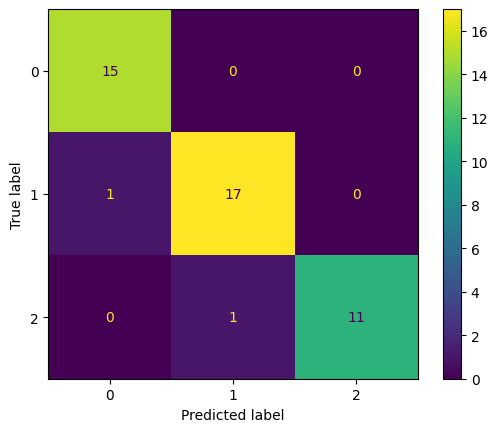

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, x_test, y_test)
plt.show()
plt.close()